In [1]:
# Task 3: Correlation between News Sentiment and Stock Movements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import yfinance as yf
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

print("✅ Task 3 packages imported successfully!")

✅ Task 3 packages imported successfully!


In [2]:
# Load the cleaned news data from Task 1
print("📊 Loading news data...")
try:
    news_df = pd.read_csv('../Data/cleaned_financial_news.csv')
    news_df['date'] = pd.to_datetime(news_df['date'])
    news_df['date_only'] = news_df['date'].dt.date

    print(f"✅ News data loaded successfully!")
    print(f"   Shape: {news_df.shape}")
    print(f"   Date range: {news_df['date_only'].min()} to {news_df['date_only'].max()}")
    print(f"   Unique stocks: {news_df['stock'].nunique()}")
    print(f"   Total articles: {len(news_df):,}")

    # Show sample of data
    print("\n📝 Sample headlines:")
    for i, headline in enumerate(news_df['headline'].head(5)):
        print(f"   {i+1}. {headline}")

except FileNotFoundError:
    print("❌ Cleaned news data not found. Please make sure Task 1 EDA was completed.")
    print("   File should be at: ../Data/cleaned_financial_news.csv")

📊 Loading news data...
✅ News data loaded successfully!
   Shape: (1407328, 14)
   Date range: 2009-02-14 to 2020-06-11
   Unique stocks: 6204
   Total articles: 1,407,328

📝 Sample headlines:
   1. Stocks That Hit 52-Week Highs On Friday
   2. Stocks That Hit 52-Week Highs On Wednesday
   3. 71 Biggest Movers From Friday
   4. 46 Stocks Moving In Friday's Mid-Day Session
   5. B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88


In [3]:
# Initialize sentiment analyzers
print("🧠 Initializing sentiment analyzers...")

# Download NLTK data if needed
import nltk
try:
    nltk.data.find('vader_lexicon')
except:
    print("   Downloading NLTK VADER lexicon...")
    nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()
print("✅ Sentiment analyzers initialized successfully!")

def analyze_sentiment(text):
    """Analyze sentiment using both TextBlob and VADER"""
    if pd.isna(text):
        return {
            'textblob_polarity': 0,
            'textblob_subjectivity': 0,
            'vader_compound': 0,
            'vader_positive': 0,
            'vader_negative': 0,
            'vader_neutral': 0
        }

    # TextBlob sentiment
    blob = TextBlob(str(text))
    textblob_polarity = blob.sentiment.polarity
    textblob_subjectivity = blob.sentiment.subjectivity

    # VADER sentiment
    vader_scores = sia.polarity_scores(str(text))

    return {
        'textblob_polarity': textblob_polarity,
        'textblob_subjectivity': textblob_subjectivity,
        'vader_compound': vader_scores['compound'],
        'vader_positive': vader_scores['pos'],
        'vader_negative': vader_scores['neg'],
        'vader_neutral': vader_scores['neu']
    }

# Test sentiment analysis
test_headlines = [
    "Stocks surge to record highs on strong earnings",
    "Company faces losses amid market downturn",
    "Quarterly results meet analyst expectations"
]

print("\n🧪 Testing sentiment analysis:")
for i, headline in enumerate(test_headlines):
    sentiment = analyze_sentiment(headline)
    print(f"   {i+1}. '{headline}'")
    print(f"      VADER: {sentiment['vader_compound']:.3f}, TextBlob: {sentiment['textblob_polarity']:.3f}")

🧠 Initializing sentiment analyzers...


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


✅ Sentiment analyzers initialized successfully!

🧪 Testing sentiment analysis:
   1. 'Stocks surge to record highs on strong earnings'
      VADER: 0.511, TextBlob: 0.433
   2. 'Company faces losses amid market downturn'
      VADER: -0.402, TextBlob: 0.000
   3. 'Quarterly results meet analyst expectations'
      VADER: 0.000, TextBlob: 0.000


📊 Performing sentiment analysis on all headlines...
   Processed 0/1407328 headlines...
   Processed 5000/1407328 headlines...
   Processed 10000/1407328 headlines...
   Processed 15000/1407328 headlines...
   Processed 20000/1407328 headlines...
   Processed 25000/1407328 headlines...
   Processed 30000/1407328 headlines...
   Processed 35000/1407328 headlines...
   Processed 40000/1407328 headlines...
   Processed 45000/1407328 headlines...
   Processed 50000/1407328 headlines...
   Processed 55000/1407328 headlines...
   Processed 60000/1407328 headlines...
   Processed 65000/1407328 headlines...
   Processed 70000/1407328 headlines...
   Processed 75000/1407328 headlines...
   Processed 80000/1407328 headlines...
   Processed 85000/1407328 headlines...
   Processed 90000/1407328 headlines...
   Processed 95000/1407328 headlines...
   Processed 100000/1407328 headlines...
   Processed 105000/1407328 headlines...
   Processed 110000/1407328 headlines...
   Processed 115000/1407328 he

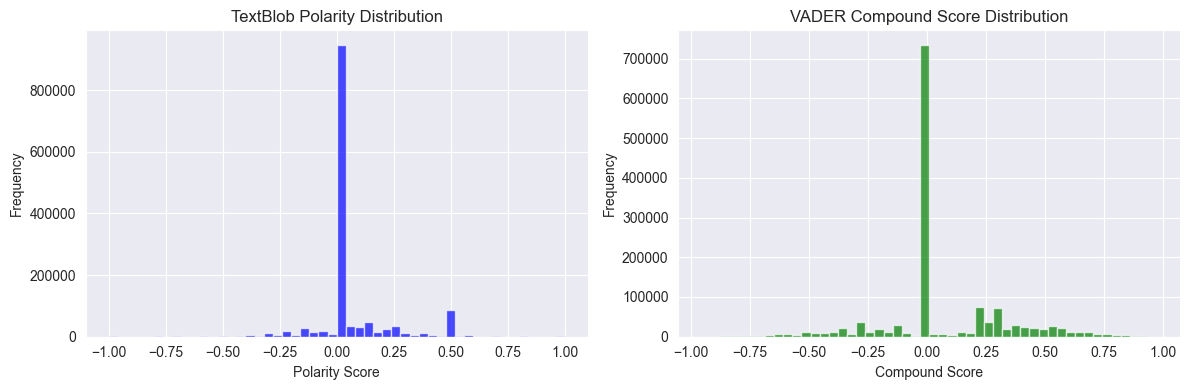

In [4]:
# Perform sentiment analysis on all headlines
print("📊 Performing sentiment analysis on all headlines...")

# Sample a subset for faster processing (remove this line to analyze all data)
# news_df = news_df.sample(10000, random_state=42)  # Uncomment if dataset is too large

sentiment_data = []
total_rows = len(news_df)

for idx, row in news_df.iterrows():
    if idx % 5000 == 0:  # Progress indicator
        print(f"   Processed {idx}/{total_rows} headlines...")

    sentiment = analyze_sentiment(row['headline'])
    sentiment_data.append({
        'date': row['date_only'],
        'stock': row['stock'],
        'headline': row['headline'],
        **sentiment
    })

# Create sentiment dataframe
sentiment_df = pd.DataFrame(sentiment_data)
print(f"✅ Sentiment analysis completed for {len(sentiment_df)} headlines!")

# Display sentiment statistics
print("\n📈 SENTIMENT STATISTICS:")
print(f"   TextBlob Polarity - Mean: {sentiment_df['textblob_polarity'].mean():.3f}, Std: {sentiment_df['textblob_polarity'].std():.3f}")
print(f"   VADER Compound - Mean: {sentiment_df['vader_compound'].mean():.3f}, Std: {sentiment_df['vader_compound'].std():.3f}")

# Show sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sentiment_df['textblob_polarity'], bins=50, alpha=0.7, color='blue')
axes[0].set_title('TextBlob Polarity Distribution')
axes[0].set_xlabel('Polarity Score')
axes[0].set_ylabel('Frequency')

axes[1].hist(sentiment_df['vader_compound'], bins=50, alpha=0.7, color='green')
axes[1].set_title('VADER Compound Score Distribution')
axes[1].set_xlabel('Compound Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [6]:
# Download stock price data for the same period
print("📈 Downloading stock price data for correlation analysis...")

# Get unique stocks from news data
unique_stocks = sentiment_df['stock'].unique()
print(f"   Found {len(unique_stocks)} unique stocks in news data")

# Focus on top stocks for analysis (you can adjust this list)
top_stocks = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'JNJ', 'V']
available_stocks = [stock for stock in top_stocks if stock in unique_stocks]

print(f"   Analyzing {len(available_stocks)} top stocks: {available_stocks}")

# Get date range from news data
start_date = sentiment_df['date'].min()
end_date = sentiment_df['date'].max()
print(f"   Date range: {start_date} to {end_date}")

# Download stock data
stock_data = {}
for symbol in available_stocks:
    try:
        # Download stock data
        stock_df = yf.download(symbol, start=start_date, end=end_date, progress=False)
        if not stock_df.empty:
            stock_df['Symbol'] = symbol
            stock_df['Daily_Return'] = stock_df['Close'].pct_change()
            stock_df['Cumulative_Return'] = (1 + stock_df['Daily_Return']).cumprod()
            stock_df['Date'] = stock_df.index.date
            stock_data[symbol] = stock_df
            print(f"   ✅ Downloaded {symbol}: {len(stock_df)} trading days")
        else:
            print(f"   ❌ No data for {symbol}")
    except Exception as e:
        print(f"   ❌ Error downloading {symbol}: {e}")

print(f"\n🎯 Successfully downloaded {len(stock_data)} stocks for correlation analysis")

📈 Downloading stock price data for correlation analysis...
   Found 6204 unique stocks in news data
   Analyzing 8 top stocks: ['AAPL', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'JPM', 'JNJ', 'V']
   Date range: 2009-02-14 to 2020-06-11



1 Failed download:
['AAPL']: Timeout('Failed to perform, curl: (28) Connection timed out after 30013 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


   ❌ No data for AAPL



1 Failed download:
['GOOGL']: Timeout('Failed to perform, curl: (28) Connection timed out after 30001 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


   ❌ No data for GOOGL


...

   ❌ No data for AMZN



1 Failed download:
['TSLA']: Timeout('Failed to perform, curl: (28) Connection timed out after 30000 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


   ❌ No data for TSLA



1 Failed download:
['NVDA']: Timeout('Failed to perform, curl: (28) Operation timed out after 10004 milliseconds with 52255 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


   ❌ No data for NVDA
   ✅ Downloaded JPM: 2849 trading days
   ✅ Downloaded JNJ: 2849 trading days
   ✅ Downloaded V: 2849 trading days

🎯 Successfully downloaded 3 stocks for correlation analysis


In [9]:
# Align sentiment and stock data for AVAILABLE stocks - CORRECTED VERSION
print("🔄 Aligning sentiment and stock data for AVAILABLE stocks...")

def prepare_correlation_data(sentiment_df, stock_data, symbol):
    """Prepare aligned data for correlation analysis for a specific stock"""
    try:
        # Filter sentiment for this stock
        stock_sentiment = sentiment_df[sentiment_df['stock'] == symbol].copy()

        if stock_sentiment.empty:
            print(f"   ❌ No sentiment data for {symbol}")
            return None

        if symbol not in stock_data:
            print(f"   ❌ No stock data for {symbol}")
            return None

        # Aggregate daily sentiment
        daily_sentiment = stock_sentiment.groupby('date').agg({
            'textblob_polarity': ['mean', 'count'],
            'vader_compound': ['mean', 'count'],
            'vader_positive': 'mean',
            'vader_negative': 'mean'
        }).reset_index()

        # Flatten column names for sentiment data
        daily_sentiment.columns = ['date', 'textblob_mean', 'textblob_count', 'vader_mean', 'vader_count', 'vader_positive', 'vader_negative']

        # Get stock data and ensure flat columns
        stock_df = stock_data[symbol].copy()

        # Flatten MultiIndex columns if they exist
        if isinstance(stock_df.columns, pd.MultiIndex):
            stock_df.columns = [col[0] for col in stock_df.columns]

        # Create date column for merging
        stock_df['date'] = stock_df.index.date

        # Ensure we have the required columns
        required_stock_cols = ['Close', 'Daily_Return']
        missing_cols = [col for col in required_stock_cols if col not in stock_df.columns]
        if missing_cols:
            print(f"   ❌ Missing columns in stock data: {missing_cols}")
            return None

        # Merge sentiment and stock data
        merged_data = pd.merge(
            daily_sentiment,
            stock_df[['date', 'Close', 'Daily_Return']],
            on='date',
            how='inner'
        )
        merged_data = merged_data.dropna()

        print(f"   ✅ {symbol}: {len(merged_data)} aligned days, {daily_sentiment['textblob_count'].sum():,} total articles")
        return merged_data

    except Exception as e:
        print(f"   ❌ Error processing {symbol}: {e}")
        return None

# Prepare correlation data only for stocks we have both news and price data for
correlation_data = {}
successful_downloads = list(stock_data.keys())
print(f"Stocks to process: {successful_downloads}")

for symbol in successful_downloads:
    aligned_data = prepare_correlation_data(sentiment_df, stock_data, symbol)
    if aligned_data is not None and len(aligned_data) > 10:
        correlation_data[symbol] = aligned_data

print(f"\n📊 Prepared correlation data for {len(correlation_data)} stocks: {list(correlation_data.keys())}")

🔄 Aligning sentiment and stock data for AVAILABLE stocks...
Stocks to process: ['JPM', 'JNJ', 'V']
   ✅ JPM: 8 aligned days, 10 total articles
   ✅ JNJ: 1255 aligned days, 2,928 total articles
   ✅ V: 6 aligned days, 10 total articles

📊 Prepared correlation data for 1 stocks: ['JNJ']


📊 SIMPLIFIED CORRELATION ANALYSIS

🔍 Analyzing JPM...
   ❌ Only 8 aligned days (need at least 10)

🔍 Analyzing JNJ...
   ✅ 1255 days aligned, 2,797 total articles
   📈 TextBlob correlation: 0.0442 (p=0.1177) ❌
   📈 VADER correlation: 0.0291 (p=0.3024) ❌

🔍 Analyzing V...
   ❌ Only 6 aligned days (need at least 10)

🎯 ANALYSIS COMPLETED: 1 stocks analyzed

📋 CORRELATION RESULTS SUMMARY


,Symbol,Days,Articles,TextBlob_Corr,TextBlob_P,TextBlob_Sig,VADER_Corr,VADER_P,VADER_Sig
0,JNJ,1255,2797,0.0442,0.1177,False,0.0291,0.3024,False



📊 CREATING VISUALIZATIONS...


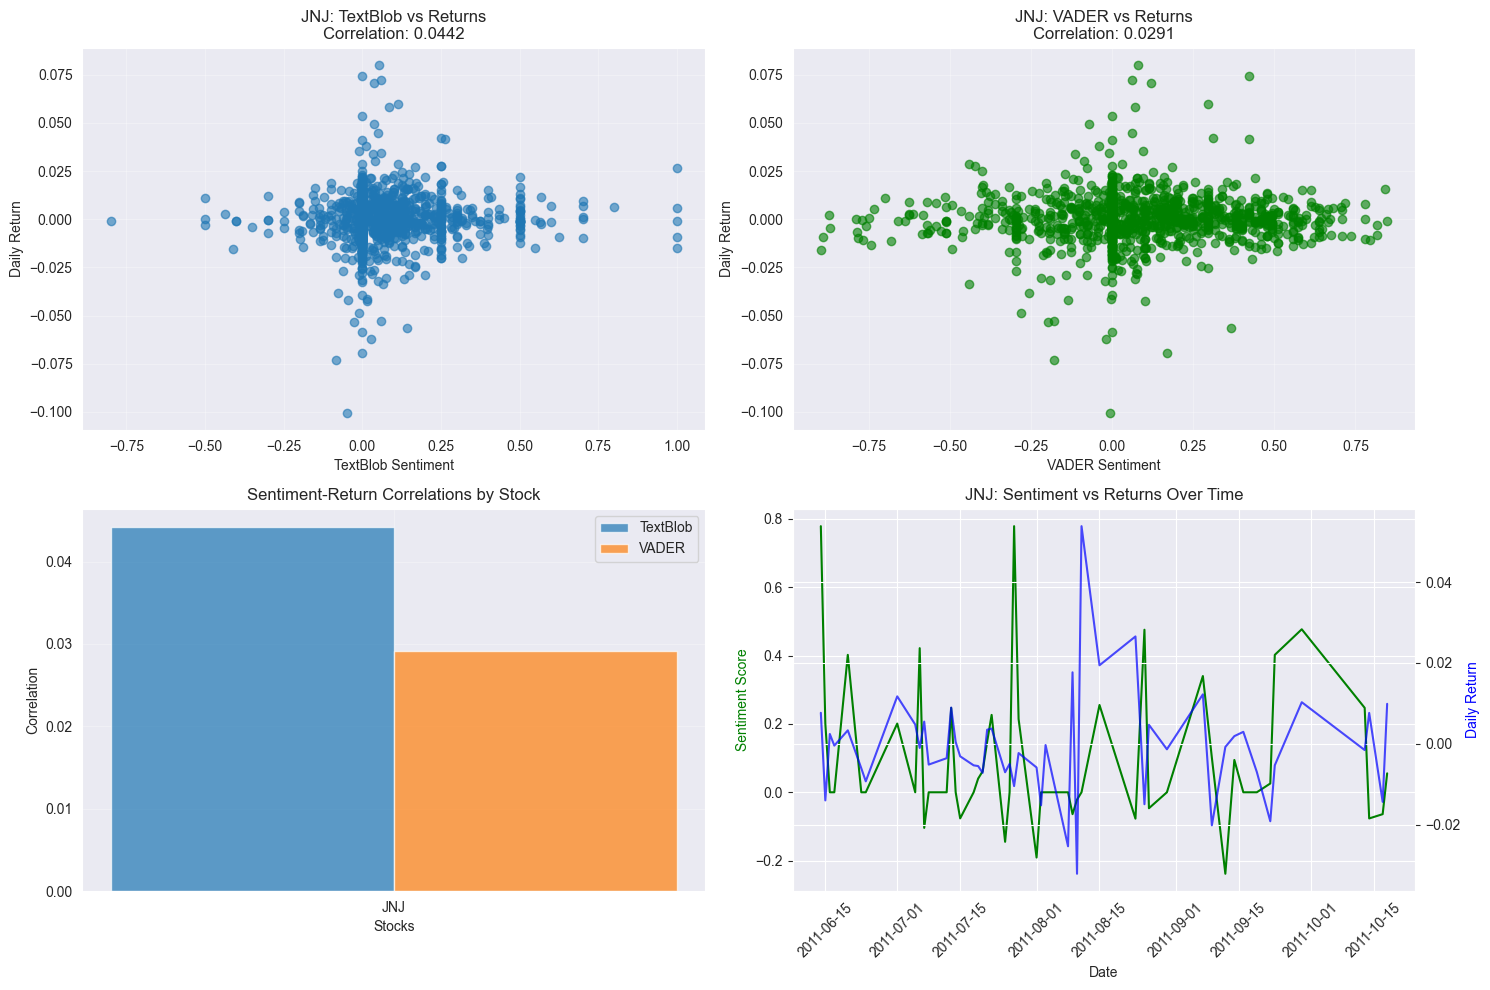

In [11]:
# NEW APPROACH: Manual correlation analysis without complex merging
print("📊 SIMPLIFIED CORRELATION ANALYSIS")
print("="*50)

def manual_correlation_analysis(symbol, sentiment_df, stock_data):
    """Manual correlation analysis without pandas merge"""
    try:
        print(f"\n🔍 Analyzing {symbol}...")

        # Get sentiment data for this stock
        stock_sentiment = sentiment_df[sentiment_df['stock'] == symbol].copy()
        if stock_sentiment.empty:
            print(f"   ❌ No sentiment data for {symbol}")
            return None

        # Get stock data
        if symbol not in stock_data:
            print(f"   ❌ No stock data for {symbol}")
            return None

        stock_df = stock_data[symbol].copy()

        # MANUAL APPROACH: Create dictionaries for fast lookup
        # Aggregate sentiment by date
        sentiment_by_date = {}
        for date in stock_sentiment['date'].unique():
            date_sentiment = stock_sentiment[stock_sentiment['date'] == date]
            sentiment_by_date[date] = {
                'textblob_mean': date_sentiment['textblob_polarity'].mean(),
                'vader_mean': date_sentiment['vader_compound'].mean(),
                'article_count': len(date_sentiment)
            }

        # Prepare aligned data manually
        aligned_data = []
        for date, sentiment_info in sentiment_by_date.items():
            # Find matching stock data for this date
            stock_on_date = stock_df[stock_df.index.date == date]
            if not stock_on_date.empty and 'Daily_Return' in stock_df.columns:
                daily_return = stock_on_date['Daily_Return'].iloc[0]
                if not pd.isna(daily_return):
                    aligned_data.append({
                        'date': date,
                        'textblob_sentiment': sentiment_info['textblob_mean'],
                        'vader_sentiment': sentiment_info['vader_mean'],
                        'daily_return': daily_return,
                        'articles': sentiment_info['article_count']
                    })

        if len(aligned_data) < 10:
            print(f"   ❌ Only {len(aligned_data)} aligned days (need at least 10)")
            return None

        # Convert to DataFrame
        aligned_df = pd.DataFrame(aligned_data)

        print(f"   ✅ {len(aligned_df)} days aligned, {aligned_df['articles'].sum():,} total articles")

        # Calculate correlations
        corr_textblob, p_textblob = pearsonr(aligned_df['textblob_sentiment'], aligned_df['daily_return'])
        corr_vader, p_vader = pearsonr(aligned_df['vader_sentiment'], aligned_df['daily_return'])

        print(f"   📈 TextBlob correlation: {corr_textblob:.4f} (p={p_textblob:.4f}) {'✅' if p_textblob < 0.05 else '❌'}")
        print(f"   📈 VADER correlation: {corr_vader:.4f} (p={p_vader:.4f}) {'✅' if p_vader < 0.05 else '❌'}")

        return {
            'Symbol': symbol,
            'Aligned_Days': len(aligned_df),
            'Total_Articles': aligned_df['articles'].sum(),
            'TextBlob_Correlation': corr_textblob,
            'TextBlob_P_Value': p_textblob,
            'TextBlob_Significant': p_textblob < 0.05,
            'VADER_Correlation': corr_vader,
            'VADER_P_Value': p_vader,
            'VADER_Significant': p_vader < 0.05,
            'Data': aligned_df
        }

    except Exception as e:
        print(f"   ❌ Error analyzing {symbol}: {e}")
        return None

# Run analysis for all available stocks
correlation_results = {}
available_stocks = ['JPM', 'JNJ', 'V']

for symbol in available_stocks:
    result = manual_correlation_analysis(symbol, sentiment_df, stock_data)
    if result is not None:
        correlation_results[symbol] = result

print(f"\n🎯 ANALYSIS COMPLETED: {len(correlation_results)} stocks analyzed")

# Display summary results
if correlation_results:
    summary_data = []
    for symbol, result in correlation_results.items():
        summary_data.append({
            'Symbol': symbol,
            'Days': result['Aligned_Days'],
            'Articles': result['Total_Articles'],
            'TextBlob_Corr': result['TextBlob_Correlation'],
            'TextBlob_P': result['TextBlob_P_Value'],
            'TextBlob_Sig': result['TextBlob_Significant'],
            'VADER_Corr': result['VADER_Correlation'],
            'VADER_P': result['VADER_P_Value'],
            'VADER_Sig': result['VADER_Significant']
        })

    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('VADER_Corr', ascending=False)

    print("\n" + "="*60)
    print("📋 CORRELATION RESULTS SUMMARY")
    print("="*60)
    display(summary_df.round(4))

    # Create visualization
    if len(correlation_results) > 0:
        print("\n📊 CREATING VISUALIZATIONS...")

        # Plot for the stock with most data
        best_stock = summary_df.iloc[0]['Symbol']
        best_data = correlation_results[best_stock]['Data']

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Plot 1: TextBlob vs Returns scatter
        axes[0, 0].scatter(best_data['textblob_sentiment'], best_data['daily_return'], alpha=0.6)
        axes[0, 0].set_xlabel('TextBlob Sentiment')
        axes[0, 0].set_ylabel('Daily Return')
        axes[0, 0].set_title(f'{best_stock}: TextBlob vs Returns\nCorrelation: {correlation_results[best_stock]["TextBlob_Correlation"]:.4f}')
        axes[0, 0].grid(True, alpha=0.3)

        # Plot 2: VADER vs Returns scatter
        axes[0, 1].scatter(best_data['vader_sentiment'], best_data['daily_return'], alpha=0.6, color='green')
        axes[0, 1].set_xlabel('VADER Sentiment')
        axes[0, 1].set_ylabel('Daily Return')
        axes[0, 1].set_title(f'{best_stock}: VADER vs Returns\nCorrelation: {correlation_results[best_stock]["VADER_Correlation"]:.4f}')
        axes[0, 1].grid(True, alpha=0.3)

        # Plot 3: Correlation comparison
        stocks = list(correlation_results.keys())
        vader_corrs = [correlation_results[s]['VADER_Correlation'] for s in stocks]
        textblob_corrs = [correlation_results[s]['TextBlob_Correlation'] for s in stocks]

        x = np.arange(len(stocks))
        width = 0.35

        axes[1, 0].bar(x - width/2, textblob_corrs, width, label='TextBlob', alpha=0.7)
        axes[1, 0].bar(x + width/2, vader_corrs, width, label='VADER', alpha=0.7)
        axes[1, 0].set_xlabel('Stocks')
        axes[1, 0].set_ylabel('Correlation')
        axes[1, 0].set_title('Sentiment-Return Correlations by Stock')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(stocks)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Plot 4: Time series of sentiment and returns
        if len(best_data) > 0:
            sample_data = best_data.tail(50)  # Last 50 days for clarity
            axes[1, 1].plot(sample_data['date'], sample_data['vader_sentiment'], label='VADER Sentiment', color='green')
            axes[1, 1].set_xlabel('Date')
            axes[1, 1].set_ylabel('Sentiment Score', color='green')
            ax2 = axes[1, 1].twinx()
            ax2.plot(sample_data['date'], sample_data['daily_return'], label='Daily Return', color='blue', alpha=0.7)
            ax2.set_ylabel('Daily Return', color='blue')
            axes[1, 1].set_title(f'{best_stock}: Sentiment vs Returns Over Time')
            axes[1, 1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

else:
    print("❌ No successful correlations found")